# 501: prepare full df, overview Scenario Group Analysis

This notebook calculates the probability that warming declines after net-zero emissions are achieved, and the magnitude of this decline,
comparing four groups of scenarios:
1. **Scenarios (NZCO2)**: Scenarios with "NZCO2" in the label
2. **Scenarios (NZGHG)**: Scenarios with "NZKyoto" in the label
3. **Stylised Variants (NZCO2-hold")**
4. **Stylised Variants (NZGHG-hold")**


**Criteria for decline:**
- Delta warming (NZCO2 - 2100) > 0°C

In [57]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dotenv.load_dotenv()

True

In [58]:
# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

# Guardrails for classifying decline
PEAK_YEAR_THRESHOLD = 2100  # Peak must occur before this year
DELTA_WARMING_THRESHOLD = 0.0  # Minimum decline in °C to count as decline

In [59]:
# Input metrics file - uses combined manifest from 401
MANIFEST_ID = "regenerated"
#METRICS_FILE = OUTPUT_FOLDER / f"500_gsat_metrics_{MANIFEST_ID}.csv"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv"

## Load and Filter Data

In [60]:
# Load 500b component metrics
all_df = pd.read_csv(OUTPUT_FOLDER / METRICS_FILE)

# Filter to rows where net-zero CO2 year extraction was possible
all_df = all_df[all_df["GSAT|ANTHROPOGENIC|netzero_co2"].notna()].copy()
print(f"Rows with valid NZCO2-year extraction: {len(all_df)}")

# Classify scenarios into groups
all_df["scenario_group"] = all_df["scenario"].apply(
    lambda x: "Stylised Variants (NZCO2-hold)" if "NZCO2" in x
    else ("Stylised Variants (NZGHG-hold)" if "NZKyoto" in x else "Scenarios (NZCO2)")
)
# Build set of (model, stripped_scenario) keys from NZKyoto
nzkyoto_combos = set(
    all_df[all_df["scenario_group"] == "Stylised Variants (NZGHG-hold)"]
    .assign(scenario_key=lambda d: d["scenario"].str.replace("_NZKyoto", "", regex=False))
    [["model", "scenario_key"]]
    .itertuples(index=False, name=None)
)

# Find Base rows whose (model, scenario) pair matches a stripped NZKyoto combo
base_df = all_df[all_df["scenario_group"] == "Scenarios (NZCO2)"]
mask = base_df.apply(
    lambda r: (r["model"], r["scenario"]) in nzkyoto_combos, axis=1
)
base_nzghg = base_df[mask].copy()
base_nzghg["scenario_group"] = "Scenarios (NZGHG)"

# Concatenate without overwriting all_df
all_df_extended = pd.concat([all_df, base_nzghg], ignore_index=True)

# Show group counts
group_counts = (
    all_df_extended
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby("scenario_group")
    .agg(
        n_rows=("run_id", "count"),
        n_unique_model_scenarios=("scenario", "count")
    )
)

print("\nScenario group summary:")
group_counts

Rows with valid NZCO2-year extraction: 1173000

Scenario group summary:


,n_rows,n_unique_model_scenarios
scenario_group,,
Scenarios (NZCO2),784,784
Scenarios (NZGHG),387,387
Stylised Variants (NZCO2-hold),784,784
Stylised Variants (NZGHG-hold),387,387


## Classify Ensemble Members

In [61]:
all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|netzero_co2"]
all_df_extended["GSAT|ANTHROPOGENIC|delta_peak_gsat"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|peak"]

In [62]:
# Save here - BEFORE is_decline is added below - so the shared file other notebooks (502, 503, 505, 506, 507) load stays criterion-neutral (just scenario_group and the delta columns). is_decline is this notebook's own classification opinion and should not ride along into a file other notebooks treat as a stable, shared input.
all_df_extended.to_csv(OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv")

In [63]:
# Apply guardrails to classify each ensemble member as "decline" or not
all_df_extended["is_decline"] = (
    (all_df_extended["peak_year"] < PEAK_YEAR_THRESHOLD) &
    (all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] < DELTA_WARMING_THRESHOLD)
)

# Summary by group
decline_summary = all_df_extended.groupby("scenario_group").agg(
    total_members=("is_decline", "count"),
    decline_members=("is_decline", "sum"),
)
decline_summary["no_decline_members"] = decline_summary["total_members"] - decline_summary["decline_members"]
decline_summary["pct_decline"] = (decline_summary["decline_members"] / decline_summary["total_members"] * 100).round(1)
print("Decline classification by scenario group 2100 - NZCO2 year:")
decline_summary

Decline classification by scenario group 2100 - NZCO2 year:


,total_members,decline_members,no_decline_members,pct_decline
scenario_group,,,,
Scenarios (NZCO2),470400,388118,82282,82.5
Scenarios (NZGHG),232200,216190,16010,93.1
Stylised Variants (NZCO2-hold),470400,327291,143109,69.6
Stylised Variants (NZGHG-hold),232200,208938,23262,90.0


In [64]:
# Apply guardrails to classify each ensemble member as "decline" or not
all_df_extended_gsat = all_df_extended.copy()

all_df_extended_gsat["is_decline"] = (
    (all_df_extended_gsat["peak_year"] < PEAK_YEAR_THRESHOLD) &
    (all_df_extended_gsat["GSAT|ANTHROPOGENIC|delta_peak_gsat"] < DELTA_WARMING_THRESHOLD)
)

# Summary by group
decline_summary_gsat = all_df_extended_gsat.groupby("scenario_group").agg(
    total_members=("is_decline", "count"),
    decline_members=("is_decline", "sum"),
)
decline_summary_gsat["no_decline_members"] = decline_summary_gsat["total_members"] - decline_summary_gsat["decline_members"]
decline_summary_gsat["pct_decline"] = (decline_summary_gsat["decline_members"] / decline_summary_gsat["total_members"] * 100).round(1)
print("Decline classification by scenario group 2100 - peak GSAT year:")
decline_summary_gsat

Decline classification by scenario group 2100 - peak GSAT year:


,total_members,decline_members,no_decline_members,pct_decline
scenario_group,,,,
Scenarios (NZCO2),470400,416145,54255,88.5
Scenarios (NZGHG),232200,228087,4113,98.2
Stylised Variants (NZCO2-hold),470400,353030,117370,75.0
Stylised Variants (NZGHG-hold),232200,220729,11471,95.1


## Table 1a Probability of GSAT decline from NZCO2 year

In [65]:
# Group by model, scenario, and scenario_group, calculate probability
decline_prob = all_df_extended.groupby(["scenario_group", "model", "scenario"]).agg(
    n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
    n_decline=pd.NamedAgg(column="is_decline", aggfunc="sum"),
).reset_index()

# Calculate probability
decline_prob["prob_decline"] = decline_prob["n_decline"] / decline_prob["n_ensemble"]
decline_prob["prob_decline_pct"] = (decline_prob["prob_decline"] * 100).round(1)

print(f"Calculated probabilities for {len(decline_prob)} scenarios")
decline_prob.head(10)

Calculated probabilities for 2342 scenarios


,scenario_group,model,scenario,n_ensemble,n_decline,prob_decline,prob_decline_pct
0,Scenarios (NZCO2),AIM/CGE 2.0,SSP1-19,600,589,0.981667,98.2
1,Scenarios (NZCO2),AIM/CGE 2.0,SSP2-19,600,598,0.996667,99.7
2,Scenarios (NZCO2),AIM/CGE 2.0,SSP2-26,600,494,0.823333,82.3
3,Scenarios (NZCO2),AIM/CGE 2.0,SSP3-34,600,150,0.250000,25.0
4,Scenarios (NZCO2),AIM/CGE 2.0,SSP4-26,600,527,0.878333,87.8
5,Scenarios (NZCO2),AIM/CGE 2.0,SSP5-26,600,446,0.743333,74.3
6,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NDC2030i_1000,600,494,0.823333,82.3
7,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_1000,600,180,0.300000,30.0
8,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_400,600,598,0.996667,99.7
9,Scenarios (NZCO2),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Cost-Effective,600,481,0.801667,80.2


In [66]:
# Create structured summary table for each group
def create_group_summary(df, group_name):
    """Create summary statistics for a scenario group."""
    group_data = df[df["scenario_group"] == group_name]
    
    summary = {
        "Group": group_name,
        "N Scenarios": len(group_data),
        "Median (%)": group_data["prob_decline_pct"].median().round(1),
        "5th Pctl (%)": group_data["prob_decline_pct"].quantile(0.05).round(1),
        "17th Pctl (%)": group_data["prob_decline_pct"].quantile(0.17).round(1),
        "10th Pctl (%)": group_data["prob_decline_pct"].quantile(0.1).round(1),
        "34th Pctl (%)": group_data["prob_decline_pct"].quantile(0.34).round(1),
        "67th Pctl (%)": group_data["prob_decline_pct"].quantile(0.67).round(1),
        "83rd Pctl (%)": group_data["prob_decline_pct"].quantile(0.83).round(1),
        "90th Pctl (%)": group_data["prob_decline_pct"].quantile(0.9).round(1),
        "95th Pctl (%)": group_data["prob_decline_pct"].quantile(0.95).round(1),
    }
    return summary

# Create summary for each group
summaries = []
for group in ["Scenarios (NZCO2)", "Scenarios (NZGHG)", "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZGHG-hold)"]:
    summaries.append(create_group_summary(decline_prob, group))

In [67]:
rename_map = {
    "Scenarios (NZCO2)":         "Scenarios\n(NZCO2)",
    "Scenarios (NZGHG)":         "Scenarios\n(NZGHG)",
    "Stylised Variants (NZCO2-hold)": "Stylised Variants\n(NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)": "Stylised Variants\n(NZGHG-hold)",
}

In [68]:
groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

def format_decline_summary(df, group_name):
    group_data = df[df["scenario_group"] == group_name]["prob_decline_pct"]
    return [
        f"{group_data.median():.1f}%",
        f"({group_data.quantile(0.17):.1f} to {group_data.quantile(0.83):.1f})",
        f"({group_data.quantile(0.05):.1f} to {group_data.quantile(0.95):.1f})",
    ]

stat_labels = [
    "Median [%]",
    "(p34 to p67) [%]",
    "(p17 to p83) [%]",
    "(p10 to p90) [%]",
    "(p05 to p95) [%]",
    "N scenarios",

]

def format_decline_summary(df, group_name):
    group_data = df[df["scenario_group"] == group_name]["prob_decline_pct"]
    return [
        f"{group_data.median():.1f}",
        f"({group_data.quantile(0.34):.1f} to {group_data.quantile(0.67):.1f})",
        f"({group_data.quantile(0.17):.1f} to {group_data.quantile(0.83):.1f})",
        f"({group_data.quantile(0.10):.1f} to {group_data.quantile(0.90):.1f})",
        f"({group_data.quantile(0.05):.1f} to {group_data.quantile(0.95):.1f})",
        f"{len(group_data)}",
    ]

rows = []
for stat_label, val_idx in zip(stat_labels, [0, 1, 2, 3, 4, 5]):
    row = {"Statistic": stat_label}
    for grp in groups:
        vals = format_decline_summary(decline_prob, grp)
        row[grp] = vals[val_idx]
    rows.append(row)

decline_summary_table = pd.DataFrame(rows).set_index("Statistic")
decline_summary_table.columns = decline_summary_table.columns.map(rename_map)

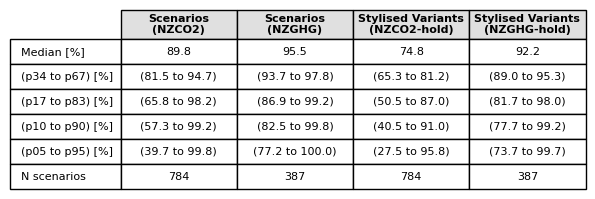

In [69]:
# Plot
fig, ax = plt.subplots(figsize=(6, len(decline_summary_table) * 0.3 + 0.1))
ax.axis("off")
table = ax.table(
    cellText=decline_summary_table.values,
    colLabels=decline_summary_table.columns,
    rowLabels=list(decline_summary_table.index),
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

header_height = 0.2
for col_idx in range(len(decline_summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

plt.show()

## Table 1b magnitude of GSAT decline

In [70]:
## Table 1b

def calculate_scenario_stats(df, warming_column):
    """
    Calculate per-scenario statistics for delta_warming.
    
    Returns DataFrame with median, 34-67 percentile, and 5-95 percentile per scenario.
    """
    stats = df.groupby(["model", "scenario", "scenario_group"]).agg(
        n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
        median=pd.NamedAgg(column=warming_column, aggfunc="median"),
        p5=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 5)),
        p10=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 10)),
        p17=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 17)),
        p34=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 34)),
        p67=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 67)),
        p83=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 83)),
        p90=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 90)),
        p95=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 95)),
    ).reset_index()
    return stats


def calculate_group_summary(scenario_stats):
    """
    Calculate summary statistics across all scenarios in each scenario_group.

    Returns DataFrame with:
    - n_scenarios
    - median of medians
    - quantiles of scenario-level quantiles
    """

    group_summary = scenario_stats.groupby("scenario_group").apply(
        lambda df: pd.Series({
            "n_scenarios": df[["model", "scenario"]].drop_duplicates().shape[0],
            "median_of_medians": df["median"].median(),
            "p34_of_p34": df["p34"].quantile(0.34),
            "p67_of_p67": df["p67"].quantile(0.67),
            "p83_of_p83": df["p83"].quantile(0.83),
            "p5_of_p5": df["p5"].quantile(0.05),
            "p10_of_p10": df["p10"].quantile(0.1),
            "p17_of_p17": df["p17"].quantile(0.17),
            "p95_of_p95": df["p95"].quantile(0.95),
            "p90_of_p90": df["p90"].quantile(0.9),
        })
    ).reset_index()

    return group_summary

In [71]:
# Per-scenario statistics
scenario_stats = calculate_scenario_stats(all_df_extended, "GSAT|ANTHROPOGENIC|delta_netzero_co2")

# Group summary
scenarios_summary = calculate_group_summary(scenario_stats)

/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_52163/786347849.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_summary = scenario_stats.groupby("scenario_group").apply(


In [72]:
groups = ["Scenarios (NZCO2)", "Scenarios (NZGHG)", "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZGHG-hold)"]

def format_cell(row):
    """Format as median with ranges underneath."""
    if row is None:
        return ["—", "", "", "" , ""]
    return [
        f"{row['median_of_medians']:.2f}",
        f"({row['p34_of_p34']:.2f} to {row['p67_of_p67']:.2f})",
        f"({row['p17_of_p17']:.2f} to {row['p83_of_p83']:.2f})",
        f"({row['p10_of_p10']:.2f} to {row['p90_of_p90']:.2f})",
        f"({row['p5_of_p5']:.2f} to {row['p95_of_p95']:.2f})"
    ]

# Index scenarios_summary by scenario_group for easy lookup
group_summaries = scenarios_summary.set_index("scenario_group")

rows = []
for stat_label, val_idx in [
    ("Median of medians", 0),
    ("(p34 to p67)", 1),
    ("(p17 to p83)", 2),
    ("(p10 to p90)", 3),
    ("(p05 to p95)", 4),
]:
    row = {"Statistic": stat_label}
    for grp in groups:
        if grp in group_summaries.index:
            vals = format_cell(group_summaries.loc[grp])
        else:
            vals = ["—", "", "", "", ""]
        row[grp] = vals[val_idx]
    rows.append(row)

summary_table = pd.DataFrame(rows).set_index("Statistic")

# Scenario counts
counts = {
    grp: int(group_summaries.loc[grp, "n_scenarios"]) if grp in group_summaries.index else 0
    for grp in groups
}

print("Delta Warming (NZCO2 year to 2100) [°C]")
print("Scenario counts: " + ", ".join(f"{grp} (n={counts[grp]})" for grp in groups))
print()

summary_table.columns = summary_table.columns.map(rename_map)

Delta Warming (NZCO2 year to 2100) [°C]
Scenario counts: Scenarios (NZCO2) (n=784), Scenarios (NZGHG) (n=387), Stylised Variants (NZCO2-hold) (n=784), Stylised Variants (NZGHG-hold) (n=387)



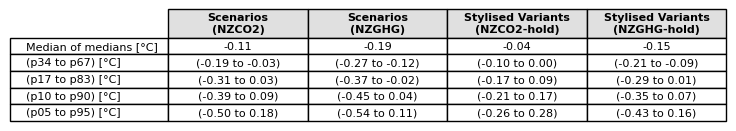

In [73]:
fig, ax = plt.subplots(figsize=(6, len(summary_table) * 0.2))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    rowLabels=[f"{col} [°C]" for col in summary_table.index],
    loc="center",
    cellLoc="center",  # centers cell contents
    colLoc="center",   # centers column headers
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1)

header_height = 0.37  # adjust to taste
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")
    
# Bold column headers (row index 0)
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")  # light grey background

plt.show()

## combined Table

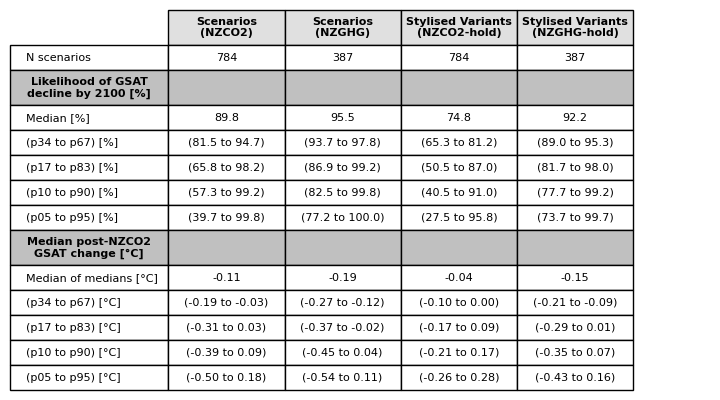

In [74]:
def make_section_header(label, n_cols):
    """Create a single-row DataFrame to use as a section header."""
    return pd.DataFrame(
        [[label] + [""] * (n_cols - 1)],
        columns=range(n_cols)
    )

# Align both tables — they should have the same columns
assert list(decline_summary_table.columns) == list(summary_table.columns)
cols = decline_summary_table.columns
n_cols = len(cols)

# Separate N scenarios row from the rest of decline_summary_table
n_scenarios_row = decline_summary_table.loc[["N scenarios"]]
decline_body = decline_summary_table.drop(index="N scenarios")

section1_label = "Likelihood of GSAT\ndecline by 2100 [%]"
section2_label = "Median post-NZCO2\nGSAT change [°C]"

row_labels = (
    list(n_scenarios_row.index) +               # N scenarios row at top
    [section1_label] +                          # section 1 header
    list(decline_body.index) +                  # rest of decline table
    [section2_label] +                          # section 2 header
    [f"{idx} [°C]" for idx in summary_table.index]
)

cell_rows = (
    n_scenarios_row.values.tolist() +           # N scenarios row
    [[""] * n_cols] +                           # section 1 header row
    decline_body.values.tolist() +
    [[""] * n_cols] +                           # section 2 header row
    summary_table.values.tolist()
)

# Section header row indices (1-indexed for table, after col headers)
n_top_rows = len(n_scenarios_row)  # = 1

section_rows = [
    n_top_rows + 1,                          # section 1 header (row 2)
    n_top_rows + 1 + len(decline_body) + 1,  # section 2 header
]

n_rows = len(row_labels)

fig, ax = plt.subplots(figsize=(8, n_rows * 0.28 + 0.5))
ax.axis("off")

table = ax.table(
    cellText=cell_rows,
    colLabels=list(cols),
    rowLabels=row_labels,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(0.75, 1.5)

# Style column headers (row 0)
header_height = 0.11
for col_idx in range(n_cols):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

# Identify section header rows (1-indexed because row 0 is col headers)
section_rows = [2, 1 + len(decline_summary_table) + 1]  # row indices in table
        
for row_idx in section_rows:
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_height(header_height)
    table[row_idx, -1].set_height(header_height)  # row label cell
    # Style the row label cell (-1 index = row label column)
    table[row_idx, -1].get_text().set_fontweight("bold")
    table[row_idx, -1].set_facecolor("#c0c0c0")
    table[row_idx, -1].get_text().set_ha("center")
    # Style the data cells (span visually by making them light grey too)
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_facecolor("#c0c0c0")
        table[row_idx, col_idx].get_text().set_fontweight("bold")


plt.savefig(PLOT_FOLDER / "Table_1.png", dpi=300, bbox_inches="tight")
plt.show()

## Supplementary plot on peak vs. NZCO2 timing

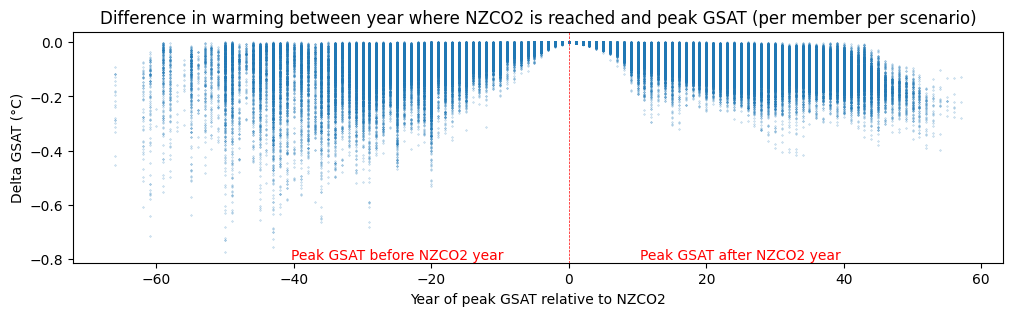

In [75]:
fig, ax = plt.subplots(figsize=(12, 3))

subset = all_df_extended[all_df_extended["scenario_group"]=="Scenarios (NZCO2)"]

x = subset["year_netzero_co2"] - subset["peak_year"]
y = subset["GSAT|ANTHROPOGENIC|netzero_co2"] - subset["GSAT|ANTHROPOGENIC|peak"]

ax.scatter(x, y, marker='x', s=0.8, alpha=.2)
ax.axvline(x=0, linestyle='--', c='red', linewidth=0.5)

# Position text near the top of the plot
y_text = -0.8

ax.text(
    -25,  # halfway between xmin and 0
    y_text,
    "Peak GSAT before NZCO2 year",
    ha="center",
    c="red"
)

ax.text(
    25,     # halfway between 0 and xmax
    y_text,
    "Peak GSAT after NZCO2 year",
    ha="center",
    c="red"
)

ax.set_title("Difference in warming between year where NZCO2 is reached and peak GSAT (per member per scenario)")
ax.set_xlabel("Year of peak GSAT relative to NZCO2")
ax.set_ylabel("Delta GSAT (°C)")

fig.savefig(PLOT_FOLDER / "SFigure_2.png", bbox_inches="tight", dpi=300)
    
plt.show()

# the delta is obviously negative or zero by definition, since otherwise the two years coincide

## Synthesis Table

Combines two different, deliberately-distinguished statistics into one table, using
the **strict** no-further-warming criterion throughout (`peak_year <= year_netzero_co2`
for the peak-timing check, matching 505/502), for both of the two mutually exclusive
strict sub-categories:
- scenarios with no further warming post-NZCO2 (peak at or before NZCO2, 2100 GSAT at
  or below the NZCO2-year level)
- scenarios with post-NZCO2 peak-and-decline GSAT (peak occurs *after* NZCO2, but 2100
  GSAT still ends up below the NZCO2-year level)

1. **Median share of ensemble members in analysed scenarios [%]** - per scenario, the
   share of its 600 MAGICC members satisfying each criterion, then the median of that
   share across scenarios (505's methodology). This represents a **typical scenario**
   in the database, in terms of these criteria - a statement about the median
   pathway, not about the population as a whole.

2. **Likelihood across the full scenario ensemble [%]** - the pooled probability for
   each criterion: pool every (scenario, member) pair and compute the fraction
   satisfying it (equal-weight per scenario, automatic since every scenario has 600
   members). Since a probability is, by definition, a mean/frequency, this pooled
   fraction *is* the actual likelihood statement - unlike the median above, which
   characterizes a representative individual scenario rather than the likelihood
   across the whole population.

   No range is reported alongside these numbers. A cluster-bootstrap CI was tested
   and found to be narrow (~1.5-3 percentage points) - but that narrowness only
   reflects how precisely these numbers are pinned down *given this specific
   784-scenario database*, not the real uncertainty in the underlying claim (which
   includes database-representativeness, model-structural, and deep scenario
   uncertainty the bootstrap can't see). Presenting it in the same "(p17 to p83)"
   notation used for genuine outcome ranges below would risk implying a similar kind
   of uncertainty is being conveyed, when it isn't - so only the point estimates are
   shown here.

3. **Post-NZCO2 GSAT change by 2100 [°C]** - the pooled median and percentiles of
   `delta_netzero_co2` directly. Unlike (2), this *is* a continuous outcome variable
   with genuine, substantively meaningful spread across the pooled population (and,
   empirically, real skew - median and mean noticeably diverge in some groups), so a
   likely range alongside the median is legitimate here, the same way IPCC blends
   climate-response and scenario/model diversity into one "likely range" for a
   continuous outcome, and reports it centered on the median (a percentile itself)
   rather than the mean, for consistency with the surrounding percentile ranges.


In [76]:
# Strict classification (same as 505/502): peak GSAT at or before the net-zero year
# AND 2100 GSAT at or below the net-zero-year level = "no further warming"; peak
# occurs after net-zero but 2100 still ends up lower = "peak-and-decline". These two
# are mutually exclusive by construction.
peak_before_nzco2 = all_df_extended["peak_year"] <= all_df_extended["year_netzero_co2"]
declines_by_2100 = all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] < 0

all_df_extended["no_further_warming_after_nzco2"] = peak_before_nzco2 & (
    all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] <= 0
)
all_df_extended["peak_and_decline_after_nzco2"] = (~peak_before_nzco2) & declines_by_2100

category_sum = (
    all_df_extended["no_further_warming_after_nzco2"].astype(int)
    + all_df_extended["peak_and_decline_after_nzco2"].astype(int)
)
assert (category_sum <= 1).all(), "no_further_warming_after_nzco2 and peak_and_decline_after_nzco2 should be mutually exclusive"

print("Member-level classification (all groups combined):")
all_df_extended[["no_further_warming_after_nzco2", "peak_and_decline_after_nzco2"]].mean().mul(100).round(1)


Member-level classification (all groups combined):


no_further_warming_after_nzco2    65.7
peak_and_decline_after_nzco2      15.5
dtype: float64

In [77]:
def per_scenario_probability_median(df, group, criterion_col):
    """Median, across scenarios in `group`, of each scenario's own share of members
    satisfying `criterion_col` (505's per-scenario-probability methodology, reduced
    to just the median point value)."""
    per_scenario_share = (
        df[df["scenario_group"] == group]
        .groupby(["model", "scenario"])[criterion_col]
        .mean() * 100
    )
    return per_scenario_share.median()


median_share_results = pd.DataFrame({
    "no further warming": [per_scenario_probability_median(all_df_extended, g, "no_further_warming_after_nzco2") for g in groups],
    "peak-and-decline": [per_scenario_probability_median(all_df_extended, g, "peak_and_decline_after_nzco2") for g in groups],
}, index=groups)
median_share_results


,no further warming,peak-and-decline
Scenarios (NZCO2),70.166667,13.083333
Scenarios (NZGHG),74.000000,20.500000
Stylised Variants (NZCO2-hold),67.833333,3.083333
Stylised Variants (NZGHG-hold),73.333333,17.833333


In [78]:
def pooled_probability(df, group, criterion_col):
    """Pooled probability of `criterion_col` across every (scenario, member) pair in
    `group` (equal-weight-per-scenario, since each scenario has the same member
    count) - the actual likelihood statement, since a probability is by definition a
    mean/frequency. No bootstrap CI - see the markdown above for why one isn't
    reported alongside this number."""
    gdf = df[df["scenario_group"] == group]
    per_scenario = gdf.groupby(["model", "scenario"])[criterion_col].agg(["sum", "count"])
    successes = per_scenario["sum"].to_numpy(dtype=np.int64)
    totals = per_scenario["count"].to_numpy(dtype=np.int64)
    return successes.sum() / totals.sum() * 100


pooled_prob_results = pd.DataFrame({
    "no further warming": [pooled_probability(all_df_extended, g, "no_further_warming_after_nzco2") for g in groups],
    "peak-and-decline": [pooled_probability(all_df_extended, g, "peak_and_decline_after_nzco2") for g in groups],
}, index=groups)
pooled_prob_results


,no further warming,peak-and-decline
Scenarios (NZCO2),65.205570,17.302509
Scenarios (NZGHG),69.125323,23.979759
Stylised Variants (NZCO2-hold),62.921131,6.656037
Stylised Variants (NZGHG-hold),68.993971,20.987941


In [79]:
def pooled_delta_stats(df, group, value_col="GSAT|ANTHROPOGENIC|delta_netzero_co2"):
    """Pooled distribution of delta_netzero_co2 across every (scenario, member) pair
    in `group` - median and percentiles taken directly off the pooled distribution
    (no bootstrap - continuous outcome variable, not a summary parameter). Identical
    methodology to 501b/502b."""
    values = df.loc[df["scenario_group"] == group, value_col]
    n_scenarios = df.loc[df["scenario_group"] == group, ["model", "scenario"]].drop_duplicates().shape[0]
    return {
        "scenario_group": group,
        "n_scenarios": n_scenarios,
        "median": values.median(),
        "p05": values.quantile(0.05),
        "p17": values.quantile(0.17),
        "p83": values.quantile(0.83),
        "p95": values.quantile(0.95),
    }


pooled_delta_results = pd.DataFrame(
    [pooled_delta_stats(all_df_extended, g) for g in groups]
).set_index("scenario_group")
pooled_delta_results


,n_scenarios,median,p05,p17,p83,p95
scenario_group,,,,,,
Scenarios (NZCO2),784,-0.095720,-0.369717,-0.250534,0.001605,0.075764
Scenarios (NZGHG),387,-0.183834,-0.428938,-0.317634,-0.067742,0.023662
Stylised Variants (NZCO2-hold),784,-0.037198,-0.195566,-0.125662,0.042810,0.145831
Stylised Variants (NZGHG-hold),387,-0.144439,-0.322232,-0.245163,-0.041487,0.057248


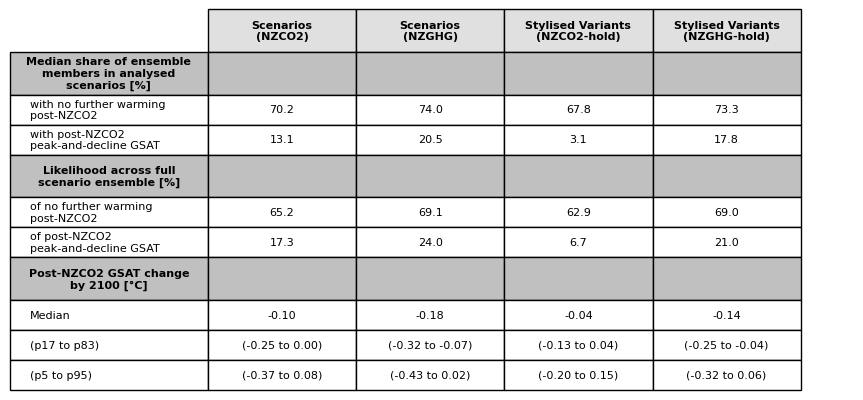

In [81]:
def fmt_pct(x):
    return f"{x:.1f}"


def fmt_degc(x):
    return f"{x:.2f}"


section1_rows = [
    ("with no further warming\npost-NZCO2", [fmt_pct(median_share_results.loc[g, "no further warming"]) for g in groups]),
    ("with post-NZCO2\npeak-and-decline GSAT", [fmt_pct(median_share_results.loc[g, "peak-and-decline"]) for g in groups]),
]

section2_rows = [
    ("of no further warming\npost-NZCO2", [fmt_pct(pooled_prob_results.loc[g, "no further warming"]) for g in groups]),
    ("of post-NZCO2\npeak-and-decline GSAT", [fmt_pct(pooled_prob_results.loc[g, "peak-and-decline"]) for g in groups]),
]

section3_rows = [
    ("Median", [fmt_degc(pooled_delta_results.loc[g, "median"]) for g in groups]),
    ("(p17 to p83)", [f"({fmt_degc(pooled_delta_results.loc[g, 'p17'])} to {fmt_degc(pooled_delta_results.loc[g, 'p83'])})" for g in groups]),
    ("(p5 to p95)", [f"({fmt_degc(pooled_delta_results.loc[g, 'p05'])} to {fmt_degc(pooled_delta_results.loc[g, 'p95'])})" for g in groups]),
]

section1_label = "Median share of ensemble\nmembers in analysed\nscenarios [%]"
section2_label = "Likelihood across full\nscenario ensemble [%]"
section3_label = "Post-NZCO2 GSAT change\nby 2100 [°C]"

col_labels = [rename_map[g] for g in groups]
n_cols = len(col_labels)

row_labels = (
    [section1_label] + [r[0] for r in section1_rows]
    + [section2_label] + [r[0] for r in section2_rows]
    + [section3_label] + [r[0] for r in section3_rows]
)

cell_rows = (
    [[""] * n_cols] + [r[1] for r in section1_rows]
    + [[""] * n_cols] + [r[1] for r in section2_rows]
    + [[""] * n_cols] + [r[1] for r in section3_rows]
)

section_row_indices = [1, 1 + len(section1_rows) + 1, 1 + len(section1_rows) + 1 + len(section2_rows) + 1]

n_rows = len(row_labels)

fig, ax = plt.subplots(figsize=(9, n_rows * 0.32 + 0.5))
ax.axis("off")

table = ax.table(
    cellText=cell_rows,
    colLabels=col_labels,
    rowLabels=row_labels,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(0.85, 1.8)

header_height = 0.15
for col_idx in range(n_cols):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

for row_idx in section_row_indices:
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_height(header_height)
        table[row_idx, col_idx].set_facecolor("#c0c0c0")
        table[row_idx, col_idx].get_text().set_fontweight("bold")
    table[row_idx, -1].set_height(header_height)
    table[row_idx, -1].get_text().set_fontweight("bold")
    table[row_idx, -1].set_facecolor("#c0c0c0")
    table[row_idx, -1].get_text().set_ha("center")

plt.savefig(PLOT_FOLDER / "501_Table_1_synthesis.png", dpi=300, bbox_inches="tight")
plt.show()
